## **Ève Castonguay**
##### Juillet 2026

In [ ]:
# Imports
from datetime import datetime
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import glob 
import numpy as np
import netCDF4 as nc
from scipy.spatial import KDTree
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import math
from scipy import stats
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_q_squared_error
import geopy.distance
import random
import re
from rapidfuzz import fuzz

# Utils file for external functions, with auto-reload
%load_ext autoreload
%autoreload 2
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
### Steps
# 1. empty dict
# 2. extraction
# 3. in darray
# 4. put in dict
# 5. concat dict by continents
# 6. put in swot_global_dset.nc

version = 'v1'

## Section 1 : Setting some variables
# 1.1 Generic
continent_list = ['na', 'af', 'as', 'eu', 'sa', 'oc']
swot_start = '2023-03-29'
swot_end = '2025-05-02'
# 1.2 Variables to extract from swot
var_config_swot = {
    'x':             ('reaches',   'x',               '',        False),
    'y':             ('reaches',   'y',               '',        False),
    'q_consensus':   ('consensus', 'consensus_q',     '',        True), 
    'q_hivdi':       ('hivdi',     'Q',               '',        True),
    'q_metroman':    ('metroman',  'allq',            '',        True),
    'q_momma':       ('momma',     'Q',               '',        True),
    'q_momma_cons':  ('momma',     'Q_constrained',   '',        True),
    'q_neobam':      ('neobam',    'q',               'q',       True),
    'q_sad':         ('sad',       'Qa',              '',        True),
    'q_sic':         ('sic4dvar',  'Q_mm',            '',        True),
    'q_sic_da':      ('sic4dvar',  'Q_da',            '',        True),
    'q_u_metroman':  ('metroman',  'q_u',             '',        True), # mv_swot & np.nan
    'q_u_neobam':    ('neobam',    'q',              'q_sd',     False), # masked array fill value np
    'q_u_sad':       ('sad',       'Q_u',              '',       True) # mv_swot
}
var_config_sword = {
    'area':          ('reaches',   'facc',            '',        False), # -9999 (arr._FillValue)
    'river_name':    ('reaches',   'river_name',      '',        False), 
    'width':         ('reaches',   'width',           '',        False), # -9999 (arr._FillValue)
    'wse':           ('reaches',   'wse',             '',        False), # -9999 (arr._FillValue)
    'sinuosity':     ('nodes',     'sinuosity',       '',        False) # -9999 (arr._FillValue)
}
var_list = list(var_config_swot.keys()) + list(var_config_sword.keys())

## Section 2 : Function - Put in DataArray
def format_dschg_swot(group_name, var_name, sub_var_name, dset_name, swot_start, swot_end, mv_swot, with_time_dim=True):
    """
    Returns discharge/other data (from swot) as a DataArray.
    e.g.    group name :    'reaches'
            var name :      'reach_id'
            sub var name :  ''
    """
    # i) get dschg/other data
    if sub_var_name == '': # empty
        main_data = dset_name[group_name][var_name][:]
    else:
        main_data = dset_name[group_name][var_name][sub_var_name][:]
    print(var_name)
    # replace all potential nans with mv_swot
    main_data = np.where(pd.isnull(main_data), mv_swot, main_data)
    # replace all potential -- (masked array np) with mv_swot
    if sub_var_name == 'q_sd':
        main_data = np.where(main_data == dset_name[group_name][var_name][sub_var_name].get_fill_value(), mv_swot, main_data)
    # replace all potential -9999 with mv_swot
    if (group_name in var_config_sword.keys()) and (var_name != 'river_name'):
        main_data = np.where(main_data == -9999, mv_swot, main_data)
    # ii) get reach ids
    rid_dim = dset_name['reaches']['reach_id'][:]
    # iii) get time data
    if with_time_dim:
        time_dim = pd.date_range(start=swot_start, end=swot_end, freq='D')
        if group_name == 'consensus':
            time_data = dset_name[group_name]['time_int'][:]
        else:
            time_data = dset_name['reaches']['time'][:]
        # iv) get missing value
        mv_swot = dset_name["consensus"]['consensus_q'].missing_value
        # vi) put in darray
        data_rfm = utils.dschg_darray(main_data, time_data, rid_dim, time_dim, mv_swot)
        data_in_darray = xr.DataArray( 
            data=data_rfm,
            dims=["reach_id","time"], 
            coords=dict(
                reach_id=rid_dim,
                time=time_dim,
            ),
            attrs=dict(units="m3/s", missing_value=np.nan # missing value of dschg is now nan
            ))
    else:
        if group_name == 'nodes':
            # get node ids, compute mean
            node_ids = dset_name["nodes"]["node_id"][:]
            node_ids_str = [str(int(nid)) for nid in node_ids]
            reach_ids = [(str(nid)[:10]+str(nid[-1])) for nid in node_ids_str]  
            df = pd.DataFrame({
                'reach_id': reach_ids,
                'sinuosity': main_data
            })
            mean_sinuosity_per_reach = df.groupby('reach_id')['sinuosity'].mean() # pd series
            # compare indexes
            real_reach_ids = [str(int(rid)) for rid in rid_dim]
            z = set(reach_ids).intersection(set(real_reach_ids)) 
            print(f'ratio of reach ids from the nodes in the reach id list: {len(z)} / {len(real_reach_ids)}')
            sinuosity_aligned = mean_sinuosity_per_reach.reindex(real_reach_ids)
            assert len(sinuosity_aligned.values) == len(rid_dim)
            # vi) put in darray
            data_in_darray = xr.DataArray(
            data=sinuosity_aligned.values,
            dims=["reach_id"], 
            coords=dict(reach_id=rid_dim,))
        else:
            # vi) put in darray
            data_in_darray = xr.DataArray(
            data=main_data,
            dims=["reach_id"], 
            coords=dict(reach_id=rid_dim,))
    return data_in_darray

## Section 3 : Loop over continents 
continent_data = {var: [] for var in var_list}
for continent in continent_list: 
    # 3.1 Reading swot
    dir_l4 = "/obs/ecastonguay/swot_data/L4_discharge/"
    file_suffix = "_sword_v16_SOS_results_unconstrained_20230502T204408_20250502T204408_20251219T163700.nc"
    single_file_name = dir_l4 + continent + file_suffix 
    dset_swot = nc.Dataset(single_file_name) 
    mv_swot = dset_swot["consensus"]['consensus_q'].missing_value
    # 3.2 Reading sword
    dir_swr = "/obs/ecastonguay/sword_data/netcdf_v16" # sword v16
    file_swr = continent + "_sword_v16.nc"
    path_swr = os.path.join(dir_swr,file_swr)
    dset_sword = nc.Dataset(path_swr)

    for var_name, (group_name, nc_var_name, sub_var_name, with_time_dim) in var_config_swot.items():
        darray = format_dschg_swot(
            group_name=group_name,
            var_name=nc_var_name,
            sub_var_name=sub_var_name,
            dset_name=dset_swot,
            swot_start=swot_start,
            swot_end=swot_end,
            mv_swot=mv_swot,
            with_time_dim=with_time_dim
        )
        continent_data[var_name].append(darray)
    for var_name, (group_name, nc_var_name, sub_var_name, with_time_dim) in var_config_sword.items():
        darray = format_dschg_swot(
            group_name=group_name,
            var_name=nc_var_name,
            sub_var_name=sub_var_name,
            dset_name=dset_sword,
            swot_start=swot_start,
            swot_end=swot_end,
            mv_swot=mv_swot,
            with_time_dim=with_time_dim
        )
        continent_data[var_name].append(darray)

## Section 4 : Concatenate
concatenated_vars = {
    var_name: xr.concat(darray_list, dim="reach_id")
    for var_name, darray_list in continent_data.items()
}

## Section 5 : Assemble
swot_global_dset = xr.Dataset(concatenated_vars)

x
y
consensus_q
Q
allq
Q
Q_constrained
q
Qa
Q_mm
Q_da
q_u
q
Q_u
facc
river_name
width
wse
sinuosity
ratio of reach ids from the nodes in the reach id list: 38046 / 38048
x
y
consensus_q
Q
allq
Q
Q_constrained
q
Qa
Q_mm
Q_da
q_u
q
Q_u
facc
river_name
width
wse
sinuosity
ratio of reach ids from the nodes in the reach id list: 20618 / 20618
x
y
consensus_q
Q
allq
Q
Q_constrained
q
Qa
Q_mm
Q_da
q_u
q
Q_u
facc
river_name
width
wse
sinuosity
ratio of reach ids from the nodes in the reach id list: 97689 / 97690
x
y
consensus_q
Q
allq
Q
Q_constrained
q
Qa
Q_mm
Q_da
q_u
q
Q_u
facc
river_name
width
wse
sinuosity
ratio of reach ids from the nodes in the reach id list: 30363 / 30363
x
y
consensus_q
Q
allq
Q
Q_constrained
q
Qa
Q_mm
Q_da
q_u
q
Q_u
facc
river_name
width
wse
sinuosity
ratio of reach ids from the nodes in the reach id list: 40678 / 40680
x
y
consensus_q
Q
allq
Q
Q_constrained
q
Qa
Q_mm
Q_da
q_u
q
Q_u
facc
river_name
width
wse
sinuosity
ratio of reach ids from the nodes in the reach id 

In [ ]:
q_var_list = ['q_consensus', 'q_hivdi', 'q_metroman', 'q_momma', 'q_momma_cons', 'q_neobam', 'q_sad', 'q_sic', 'q_sic_da']

################################### Discharge amplitude (on all time-series)
new_names_ampli = ['ampli_consensus', 'ampli_hivdi', 'ampli_metroman', 'ampli_momma', 'ampli_momma_cons', 'ampli_neobam', 'ampli_sad', 'ampli_sic', 'ampli_sic_da']

def q_amplitude(q_darray, new_name):
    """
    Computes the amplitude of discharge (max-min) for each station in the DataArray.
    Puts new DataArray with the amplitude values in DataSet.
    """
    min_q = q_darray.min(dim="time", skipna=True)
    max_q = q_darray.max(dim="time", skipna=True)
    amplitude = max_q - min_q

    ampli_darray = xr.DataArray(
        data=amplitude,
        dims=["reach_id"], 
        coords=dict(
            reach_id=q_darray.reach_id))
    
    swot_global_dset[new_name] = ampli_darray

for i, var in enumerate(q_var_list):
    q_darray = swot_global_dset[var]
    new_name = new_names_ampli[i]
    q_amplitude(q_darray, new_name)

################################### Mean discharge for a station
new_names_mean = ['mean_q_consensus', 'mean_q_hivdi', 'mean_q_metroman', 'mean_q_momma', 'mean_q_momma_cons', 'mean_q_neobam', 'mean_q_sad', 'mean_q_sic', 'mean_q_sic_da']
for i, var in enumerate(q_var_list):
    q_darray = swot_global_dset[var]
    new_name = new_names_mean[i]
    mean_q_darray = xr.DataArray(
            data=swot_global_dset[var].mean(dim='time', skipna=True),
            dims=["reach_id"], 
            coords=dict(reach_id=swot_global_dset[var].reach_id))
    swot_global_dset[new_name] = mean_q_darray

In [15]:
## Section 6 : Save
swot_global_dset.to_netcdf(f"/obs/ecastonguay/scripts/swot_global_dset_{version}.nc")

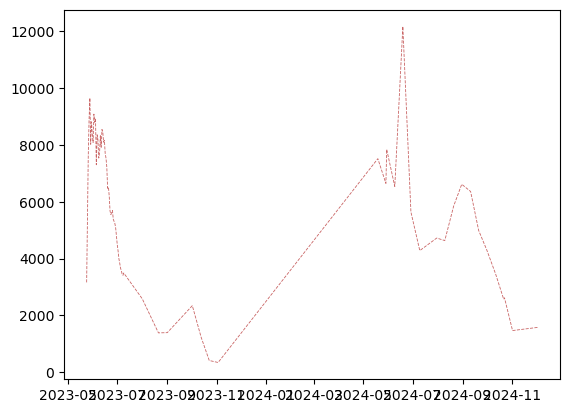

In [ ]:
# Make sure the following variables are set correctly before running the code
id = 81210300091
station_dset = swot_global_dset.sel(reach_id=id)


q_s = station_dset['q_consensus']
or_mask = ~np.isnan(q_s.values)
#plt.scatter(station_dset.seasonal_ano_s.time.values, station_dset.seasonal_ano_s.values, color='k', label='anom swot', marker='d',s=30) # ANOMALIES, NOT SEASONNAL MEAN!! don't plot in this graph (also, can be negative)
plt.plot(q_s[or_mask].time.values, q_s[or_mask].values, color='firebrick', alpha=0.7,linewidth=0.6, linestyle='--')
plt.show()  
